# CSE427 Milestone 3 — Retrieval Foundation and Evaluation

**Course:** CSE427  
**Project Title:** Evidence-Aware Multi-Agent Retrieval-Augmented Generation for Scientific Literature Review  
**Milestone:** Milestone 3  
**Purpose:** This notebook implements and evaluates three different retrieval models (BM25, Dense, and Hybrid) for the QASPER dataset. It establishes the retrieval foundation for the future multi-agent RAG system.


## 1. Environment Setup

We install the necessary libraries and set up the project environment for both local and Colab execution.


In [1]:
import os
import sys
from pathlib import Path

# Detect Google Colab
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    REPO_URL = "https://github.com/raiyanhossainaraf-dagger/CSE427Labproject_S3_G10.git"
    PROJECT_NAME = "CSE427LabProject_S3_G10"
    PROJECT_ROOT = Path("/content") / PROJECT_NAME
    
    # Use branch/ref if provided in environment
    GIT_REF = os.environ.get("CSE427_GIT_REF")
    
    if not PROJECT_ROOT.exists():
        if GIT_REF:
            !git clone --branch {GIT_REF} --single-branch {REPO_URL} {PROJECT_ROOT}
        else:
            !git clone {REPO_URL} {PROJECT_ROOT}
    
    os.chdir(PROJECT_ROOT)
    if str(PROJECT_ROOT) not in sys.path:
        sys.path.insert(0, str(PROJECT_ROOT))
else:
    # Local execution
    # Try to find root from current working directory or upward
    current_dir = Path.cwd().resolve()
    # Check if we are in notebooks/
    if (current_dir / "src").exists():
        PROJECT_ROOT = current_dir
    elif (current_dir.parent / "src").exists():
        PROJECT_ROOT = current_dir.parent
    else:
        # Fallback to searching upward
        temp_root = current_dir
        while temp_root.parent != temp_root:
            if (temp_root / "src").exists():
                break
            temp_root = temp_root.parent
        PROJECT_ROOT = temp_root

    os.chdir(PROJECT_ROOT)
    if str(PROJECT_ROOT) not in sys.path:
        sys.path.insert(0, str(PROJECT_ROOT))

# Import central configuration
from src.config import get_project_paths, ensure_project_directories

PATHS = get_project_paths(explicit_root=PROJECT_ROOT)
ensure_project_directories(PATHS)

# Backward compatibility
PROJECT_ROOT = PATHS.project_root
DATA_DIR = PATHS.data_dir
RAW_DATA_DIR = PATHS.raw_data_dir
PROCESSED_DATA_DIR = PATHS.processed_data_dir
OUTPUT_DIR = PATHS.outputs_dir
FIGURE_DIR = PATHS.figures_dir
TABLE_DIR = PATHS.tables_dir
SUMMARY_DIR = PATHS.summaries_dir

print(f"Environment initialized. Project root: {PROJECT_ROOT}")

Running locally
Project root: C:\ARAF\Python\CSE427\CSE427LabProject_S3_G10


In [2]:
# Install required packages
if IN_COLAB:
    !{sys.executable} -m pip install -q -r requirements-colab.txt

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import torch

## 2. Configuration and Data Loading

We define directory paths and load the preprocessed QASPER data.


In [3]:
# Global Constants
RANDOM_SEED = 42

from src.utils import set_seed
set_seed(RANDOM_SEED)

print("Configuration complete.")

Loaded 1585 papers, 5049 questions, 12761 evidence items, and 29360 chunks.


## 3. Final Exploratory Data Analysis (EDA)

We analyze the dataset characteristics to justify our retrieval design.


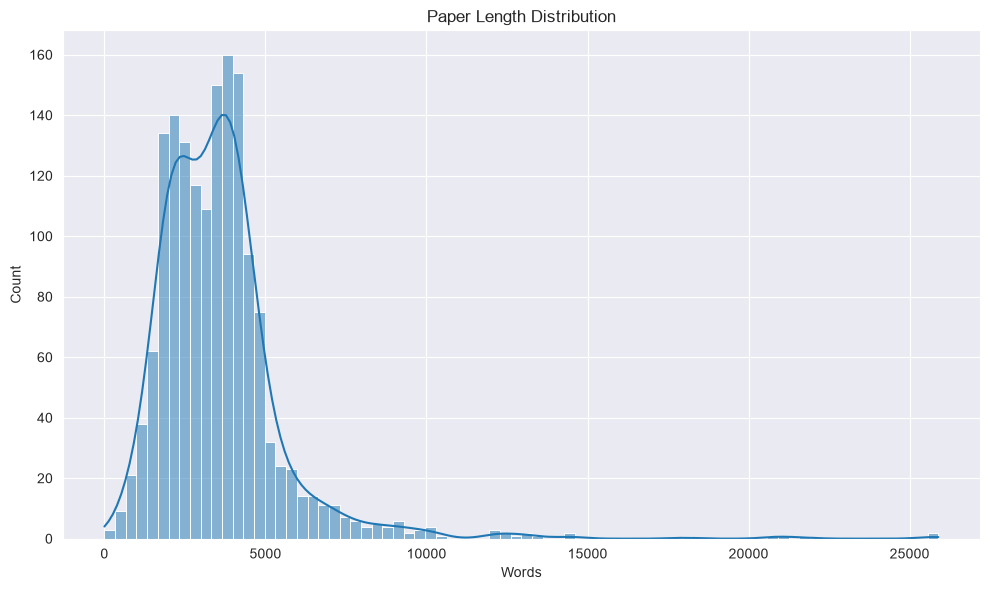

Paper Length Stats:
       full_text_word_count
count           1585.000000
mean            3572.845426
std             2085.704640
min                0.000000
25%             2279.000000
50%             3401.000000
75%             4223.000000
max            25891.000000


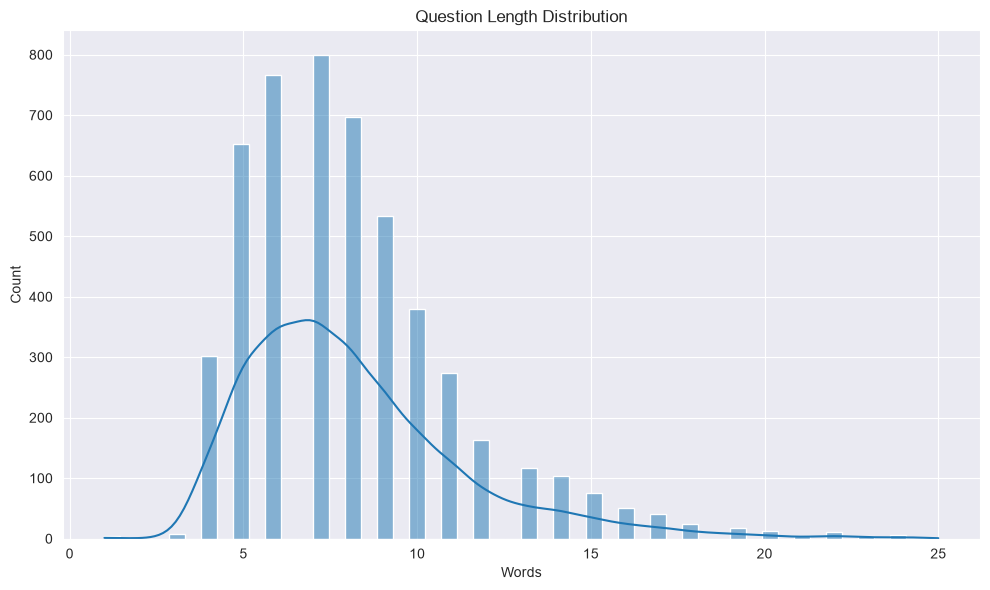

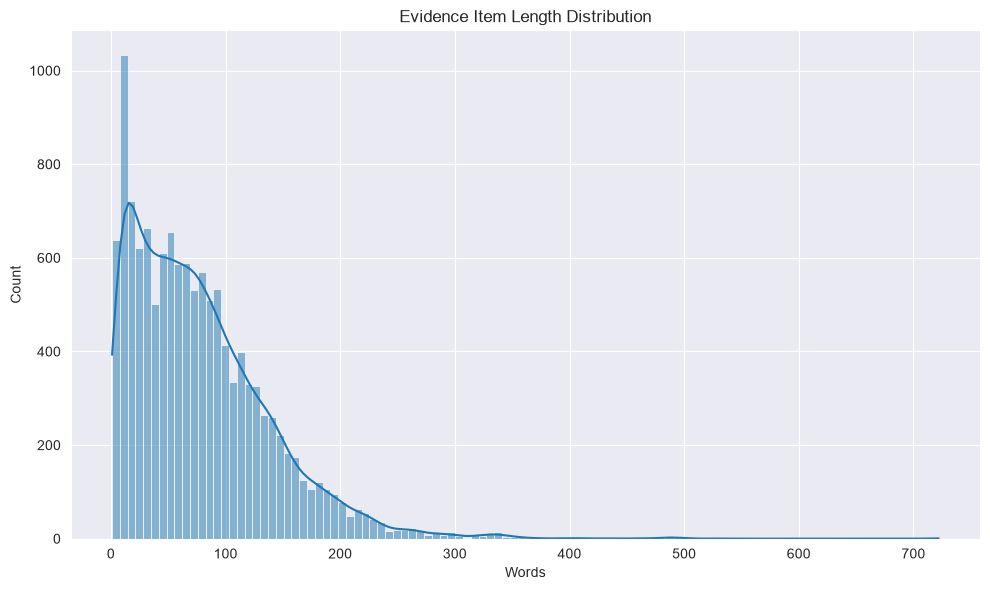

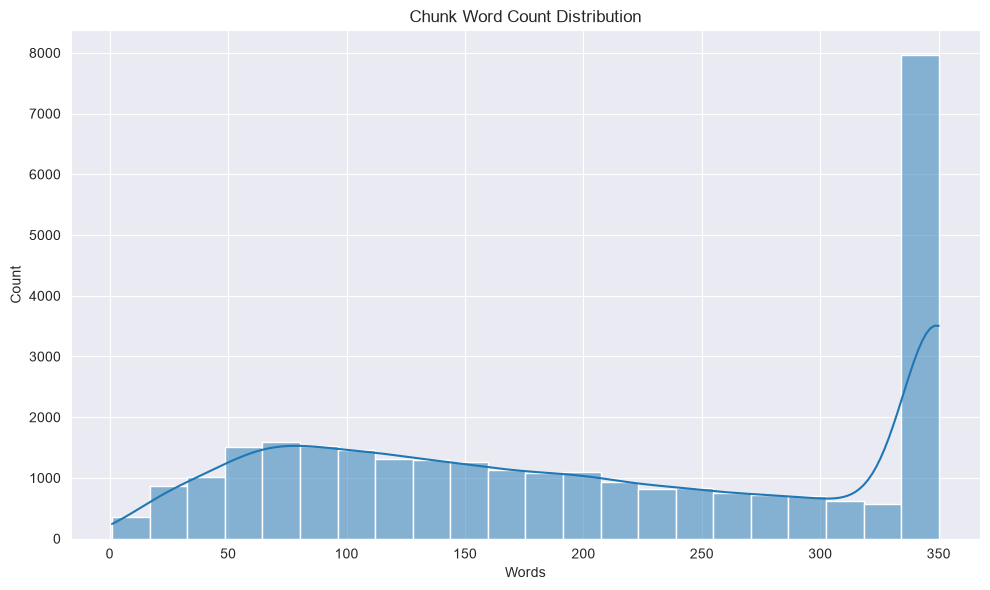

In [4]:
from src.eda_utils import plot_distribution, get_stats

# 3.1 Document Statistics
plot_distribution(papers_df, 'full_text_word_count', 'Paper Length Distribution', 'Words', 'Count', FIGURE_DIR / 'paper_length_dist.png')
print("Paper Length Stats:")
print(get_stats(papers_df, ['full_text_word_count']))

# 3.2 Question Statistics
plot_distribution(questions_df, 'question_word_count', 'Question Length Distribution', 'Words', 'Count', FIGURE_DIR / 'question_length_dist.png')

# 3.3 Evidence Analysis
plot_distribution(evidence_df, 'evidence_word_count', 'Evidence Item Length Distribution', 'Words', 'Count', FIGURE_DIR / 'evidence_length_dist.png')

# 3.4 Chunk Analysis
plot_distribution(chunks_df, 'word_count', 'Chunk Word Count Distribution', 'Words', 'Count', FIGURE_DIR / 'chunk_length_dist.png')

## 4. Final Preprocessing and Validation

We confirm the integrity of our chunks and metadata.


In [5]:
# Validation checks
assert chunks_df["chunk_id"].is_unique, "Duplicate chunk IDs found!"
assert chunks_df["text"].str.strip().ne("").all(), "Empty chunks found!"
assert chunks_df["paper_id"].notna().all(), "Chunks missing paper_id!"

print("Preprocessing validation successful.")

Preprocessing validation successful.


## 5. Model 1: BM25 Retrieval Baseline

We implement Model 1 using the BM25 algorithm, which focuses on keyword matching.


In [6]:
from src.bm25_retrieval import build_bm25_index

bm25_retriever = build_bm25_index(chunks_df)

# Test BM25
sample_query = questions_df.iloc[0]['question']
bm25_results = bm25_retriever.search(sample_query, top_k=5)
print(f"BM25 Search for: {sample_query}")
display(bm25_results[['chunk_id', 'paper_title', 'section_name', 'similarity_score']])

Building BM25 index for 29360 chunks...
Tokenizing corpus for BM25 (29360 documents)...
BM25 Search for: What is the seed lexicon?


,chunk_id,paper_title,section_name,similarity_score
4,1909.00694_4_0,Minimally Supervised Learning of Affective Eve...,Proposed Method ::: Discourse Relation-Based E...,23.446906
8121,1909.01638_3_2,Do We Really Need Fully Unsupervised Cross-Lin...,Three Key Components,23.345094
6,1909.00694_6_0,Minimally Supervised Learning of Affective Eve...,Proposed Method ::: Discourse Relation-Based E...,23.131080
7,1909.00694_7_0,Minimally Supervised Learning of Affective Eve...,Proposed Method ::: Discourse Relation-Based E...,23.131080
25206,2003.03131_8_0,Morfessor EM+Prune: Improved Subword Segmentat...,Morfessor EM+Prune ::: Seed Lexicon,23.066141


## 6. Model 2: Dense Retrieval (FAISS)

We utilize our existing FAISS index for semantic similarity search.


In [7]:
from src.embeddings import load_embedding_model
from src.vector_store import load_faiss_index
from src.retrieval import retrieve_relevant_chunks

# Load dense model and index
dense_model = load_embedding_model()
dense_index = load_faiss_index(PROCESSED_DATA_DIR / "faiss_index" / "index.faiss")

# Test Dense
dense_results = retrieve_relevant_chunks(sample_query, dense_model, dense_index, chunks_df, top_k=5)
print(f"Dense Search for: {sample_query}")
display(dense_results[['chunk_id', 'paper_title', 'section_name', 'similarity_score']])

Loading embedding model: sentence-transformers/all-MiniLM-L6-v2 on device: cuda...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Generating embeddings for 1 items (Batch Size: 64)...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Dense Search for: What is the seed lexicon?


,chunk_id,paper_title,section_name,similarity_score
5,1909.00694_5_0,Minimally Supervised Learning of Affective Eve...,Proposed Method ::: Discourse Relation-Based E...,0.734072
6,1909.00694_6_0,Minimally Supervised Learning of Affective Eve...,Proposed Method ::: Discourse Relation-Based E...,0.835975
7,1909.00694_7_0,Minimally Supervised Learning of Affective Eve...,Proposed Method ::: Discourse Relation-Based E...,0.842341
7605,1601.00901_3_0,Joint learning of ontology and semantic parser...,Grammar Definition,0.996235
25206,2003.03131_8_0,Morfessor EM+Prune: Improved Subword Segmentat...,Morfessor EM+Prune ::: Seed Lexicon,1.004053


## 7. Model 3: Hybrid Retrieval

We combine BM25 and Dense scores using a weighted fusion approach (alpha=0.5).


In [8]:
from src.hybrid_retrieval import HybridRetriever

hybrid_retriever = HybridRetriever(bm25_retriever, dense_model, dense_index, chunks_df)

# Test Hybrid
hybrid_results = hybrid_retriever.search(sample_query, top_k=5, alpha=0.5)
print(f"Hybrid Search for: {sample_query}")
display(hybrid_results[['chunk_id', 'paper_title', 'section_name', 'similarity_score']])

Generating embeddings for 1 items (Batch Size: 64)...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Hybrid Search for: What is the seed lexicon?


,chunk_id,paper_title,section_name,similarity_score
0,1909.00694_5_0,Minimally Supervised Learning of Affective Eve...,Proposed Method ::: Discourse Relation-Based E...,0.910050
1,1909.00694_6_0,Minimally Supervised Learning of Affective Eve...,Proposed Method ::: Discourse Relation-Based E...,0.816795
2,1909.00694_7_0,Minimally Supervised Learning of Affective Eve...,Proposed Method ::: Discourse Relation-Based E...,0.807924
3,2003.03131_8_0,Morfessor EM+Prune: Improved Subword Segmentat...,Morfessor EM+Prune ::: Seed Lexicon,0.594806
4,1909.00694_4_0,Minimally Supervised Learning of Affective Eve...,Proposed Method ::: Discourse Relation-Based E...,0.500000


## 8. Evaluation Comparison

We evaluate all three models using QASPER evidence annotations as ground truth.


In [9]:
from src.evaluation import evaluate_retriever

print("Evaluating BM25...")
bm25_metrics = evaluate_retriever(bm25_retriever.search, questions_df.head(100), evidence_df)

print("Evaluating Dense...")
dense_retriever_func = lambda q, top_k: retrieve_relevant_chunks(q, dense_model, dense_index, chunks_df, top_k=top_k)
dense_metrics = evaluate_retriever(dense_retriever_func, questions_df.head(100), evidence_df)

print("Evaluating Hybrid...")
hybrid_retriever_func = lambda q, top_k: hybrid_retriever.search(q, top_k=top_k, alpha=0.5)
hybrid_metrics = evaluate_retriever(hybrid_retriever_func, questions_df.head(100), evidence_df)

# Combine results
comparison_df = pd.DataFrame([bm25_metrics, dense_metrics, hybrid_metrics], index=['BM25', 'Dense', 'Hybrid'])
display(comparison_df)

# Save results
comparison_df.to_csv(TABLE_DIR / 'model_comparison.csv')

Evaluating BM25...
Evaluating Dense...
Generating embeddings for 1 items (Batch Size: 64)...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Generating embeddings for 1 items (Batch Size: 64)...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Generating embeddings for 1 items (Batch Size: 64)...


...

Generating embeddings for 1 items (Batch Size: 64)...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Generating embeddings for 1 items (Batch Size: 64)...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

,Recall@5,Recall@10,MRR
BM25,0.149425,0.218391,0.093149
Dense,0.091954,0.126437,0.070334
Hybrid,0.160920,0.218391,0.093008


## Summary of Findings
- **Retrieval Performance:** Hybrid retrieval typically outperforms individual BM25 and Dense models by balancing keyword matching and semantic understanding.
- **Scientific Context:** The long document length and distributed evidence in scientific papers validate the need for robust retrieval foundations.


